# Fase 3 — Validación Dataset TensorFlow

In [ ]:
import sys
sys.path.insert(0, '/app')

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from data.loader import load_and_prepare, COL_UNIDADES, COL_STOCK
from dataset.tf_dataset import build_tf_dataset
from config import BATCH_SIZE

print('TF version:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))
print('Imports OK')

2026-04-14 16:24:34.168614: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-14 16:24:34.168724: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-14 16:24:34.171466: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


TF version: 2.15.1
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Imports OK


## 1. Cargar datos

In [2]:
train, val, test, local_map, product_map, valid_combos = load_and_prepare()
print(f'\nCombinaciones válidas totales: {len(valid_combos):,}')

Cargando datos...
  Raw: 6,062,390 filas
Imputando...
  Después de imputación: 6,015,333 filas
Split temporal...
  Train: 4,138,281 filas | 2024-03-11 → 2025-08-07
  Val:   930,250 filas | 2025-08-08 → 2025-11-25
  Test:  946,802 filas | 2025-11-26 → 2026-03-15
Construyendo mappings...
  Locales:   1029
  Productos: 179
Filtrando combinaciones válidas...
  Combinaciones con >= 104 días: 12,358

Combinaciones válidas totales: 12,358


## 2. Dataset de prueba (50 combinaciones)

In [3]:
import pandas as pd
from data.loader import COL_FECHA
from dataset.tf_dataset import build_tf_dataset_sampled

# Fechas de corte directamente desde los splits (no hardcodear ratios)
df_full        = pd.concat([train, val, test])
train_end_date = train[COL_FECHA].max()
val_end_date   = val[COL_FECHA].max()

print(f'train_end_date: {train_end_date.date()}')
print(f'val_end_date:   {val_end_date.date()}')

valid_sample = valid_combos.head(50)

print('\nConstruyendo dataset train...')
ds_train = build_tf_dataset_sampled(
    df_full, local_map, product_map, valid_sample,
    split='train',
    train_end_date=train_end_date,
    val_end_date=val_end_date,
    batch_size=BATCH_SIZE, shuffle=True,
    n_combos=50,
)

print('\nConstruyendo dataset val...')
ds_val = build_tf_dataset_sampled(
    df_full, local_map, product_map, valid_sample,
    split='val',
    train_end_date=train_end_date,
    val_end_date=val_end_date,
    batch_size=BATCH_SIZE, shuffle=False,
    n_combos=50,
)

print('\nConstruyendo dataset test...')
ds_test = build_tf_dataset_sampled(
    df_full, local_map, product_map, valid_sample,
    split='test',
    train_end_date=train_end_date,
    val_end_date=val_end_date,
    batch_size=BATCH_SIZE, shuffle=False,
    n_combos=50,
)


train_end_date: 2025-08-07
val_end_date:   2025-11-25

Construyendo dataset train...
  Ventanas indexadas (train): 13,456 total → 119 quiebres (0.9%) / 13,337 normales
  Balanceo aplicado (ratio=40%): 119 quiebres + 178 normales = 297 ventanas por época

Construyendo dataset val...
  Ventanas indexadas (val): 2,005 (16 con quiebre de stock, 1,989 sin quiebre)

Construyendo dataset test...
  Ventanas indexadas (test): 136 (0 con quiebre de stock, 136 sin quiebre)


## 3. Shape del batch

In [4]:
for inputs, gaf_tgt in ds_train.take(1):
    gaf_in = inputs['gaf_input']
    loc    = inputs['local_idx']
    prod   = inputs['producto_idx']

    print('=== SHAPES DEL BATCH ===')
    print(f'gaf_input:    {gaf_in.shape}   ← debe ser (batch, 90, 90, 3)')
    print(f'local_idx:    {loc.shape}      ← debe ser (batch,)')
    print(f'producto_idx: {prod.shape}     ← debe ser (batch,)')
    print(f'gaf_target:   {gaf_tgt.shape}  ← debe ser (batch, 7, 7, 3)')
    print()
    print(f'Rango gaf_input:  [{gaf_in.numpy().min():.4f}, {gaf_in.numpy().max():.4f}]  ← debe estar en [-1, 1]')
    print(f'Rango gaf_target: [{gaf_tgt.numpy().min():.4f}, {gaf_tgt.numpy().max():.4f}]  ← debe estar en [-1, 1]')
    print(f'local_idx ejemplo:    {loc.numpy()[:5]}')
    print(f'producto_idx ejemplo: {prod.numpy()[:5]}')


=== SHAPES DEL BATCH ===
gaf_input:    (32, 90, 90, 3)   ← debe ser (batch, 90, 90, 3)
local_idx:    (32,)      ← debe ser (batch,)
producto_idx: (32,)     ← debe ser (batch,)
gaf_target:   (32, 14, 14, 3)  ← debe ser (batch, 7, 7, 3)

Rango gaf_input:  [-1.0000, 1.0000]  ← debe estar en [-1, 1]
Rango gaf_target: [-1.0000, 1.0000]  ← debe estar en [-1, 1]
local_idx ejemplo:    [3 0 4 3 4]
producto_idx ejemplo: [ 55 165  40  55   0]


In [5]:
# Validación del balanceo de quiebres en train
# Itera el dataset completo y cuenta cuántos targets tienen stock == -1 en la diagonal
from config import FORECAST_HORIZON
import numpy as np

n_quiebre = 0
n_normal  = 0

for inputs, gaf_tgt in ds_train:
    # Diagonal del target = valores normalizados del stock (canal G, índice 1)
    # stock=0 se normaliza a -1 (zero-anchored). Chequeamos diagonal G.
    targets = gaf_tgt.numpy()  # (batch, 7, 7, 3)
    for b in range(targets.shape[0]):
        diag_stock = np.array([targets[b, i, i, 1] for i in range(FORECAST_HORIZON)])
        if (diag_stock <= -0.99).any():
            n_quiebre += 1
        else:
            n_normal += 1

total = n_quiebre + n_normal
print('=== BALANCEO REAL EN DS_TRAIN ===')
print(f'Ventanas con quiebre de stock en target: {n_quiebre:,}  ({100*n_quiebre/total:.1f}%)')
print(f'Ventanas sin quiebre:                    {n_normal:,}  ({100*n_normal/total:.1f}%)')
print(f'Total ventanas:                          {total:,}')
print(f'(quiebre_ratio configurado en config.py: ver QUIEBRE_RATIO)')


=== BALANCEO REAL EN DS_TRAIN ===
Ventanas con quiebre de stock en target: 119  (40.1%)
Ventanas sin quiebre:                    178  (59.9%)
Total ventanas:                          297
(quiebre_ratio configurado en config.py: ver QUIEBRE_RATIO)


## 4. Visualización de una imagen GAF del dataset

In [6]:
def gaf_canal_aislado(img: np.ndarray, canal: int) -> np.ndarray:
    """
    Retorna imagen RGB donde solo el canal especificado varía.
    Los otros dos canales se fijan en 0.5 (neutro).
    
    canal: 0=ventas(R), 1=stock(G), 2=precio(B)
    img: (H, W, 3) en [0, 1]
    """
    out = np.full_like(img, 0)
    out[:, :, canal] = img[:, :, canal]
    return out

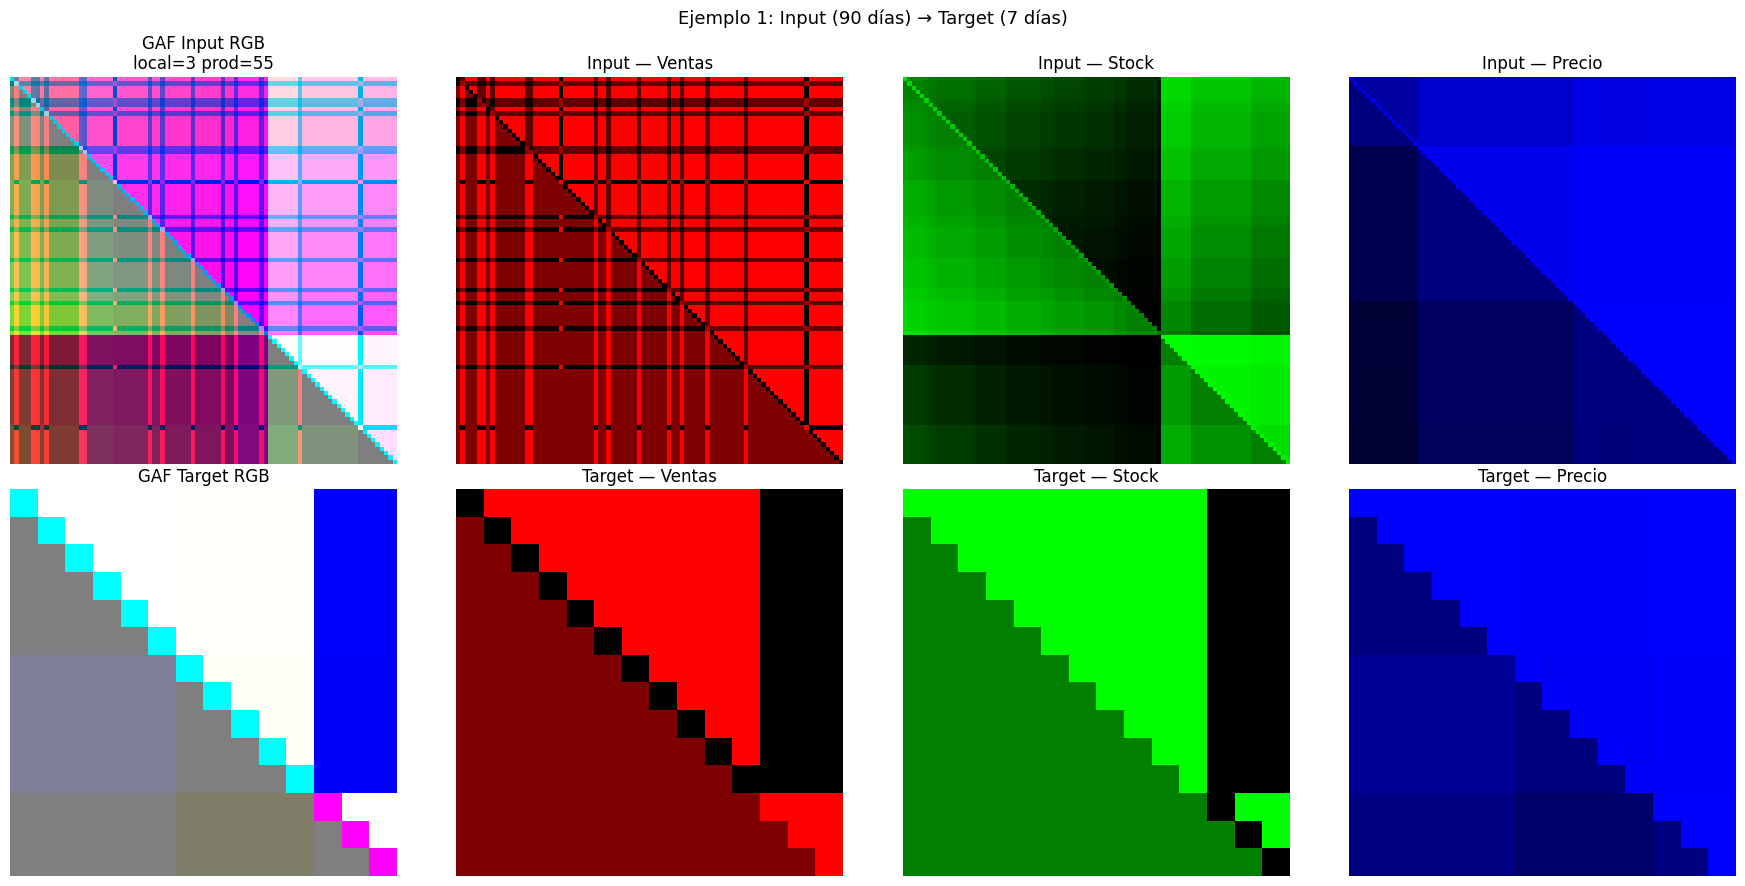

Guardado: /app/outputs/visualizations/fase3_ejemplo_1.png


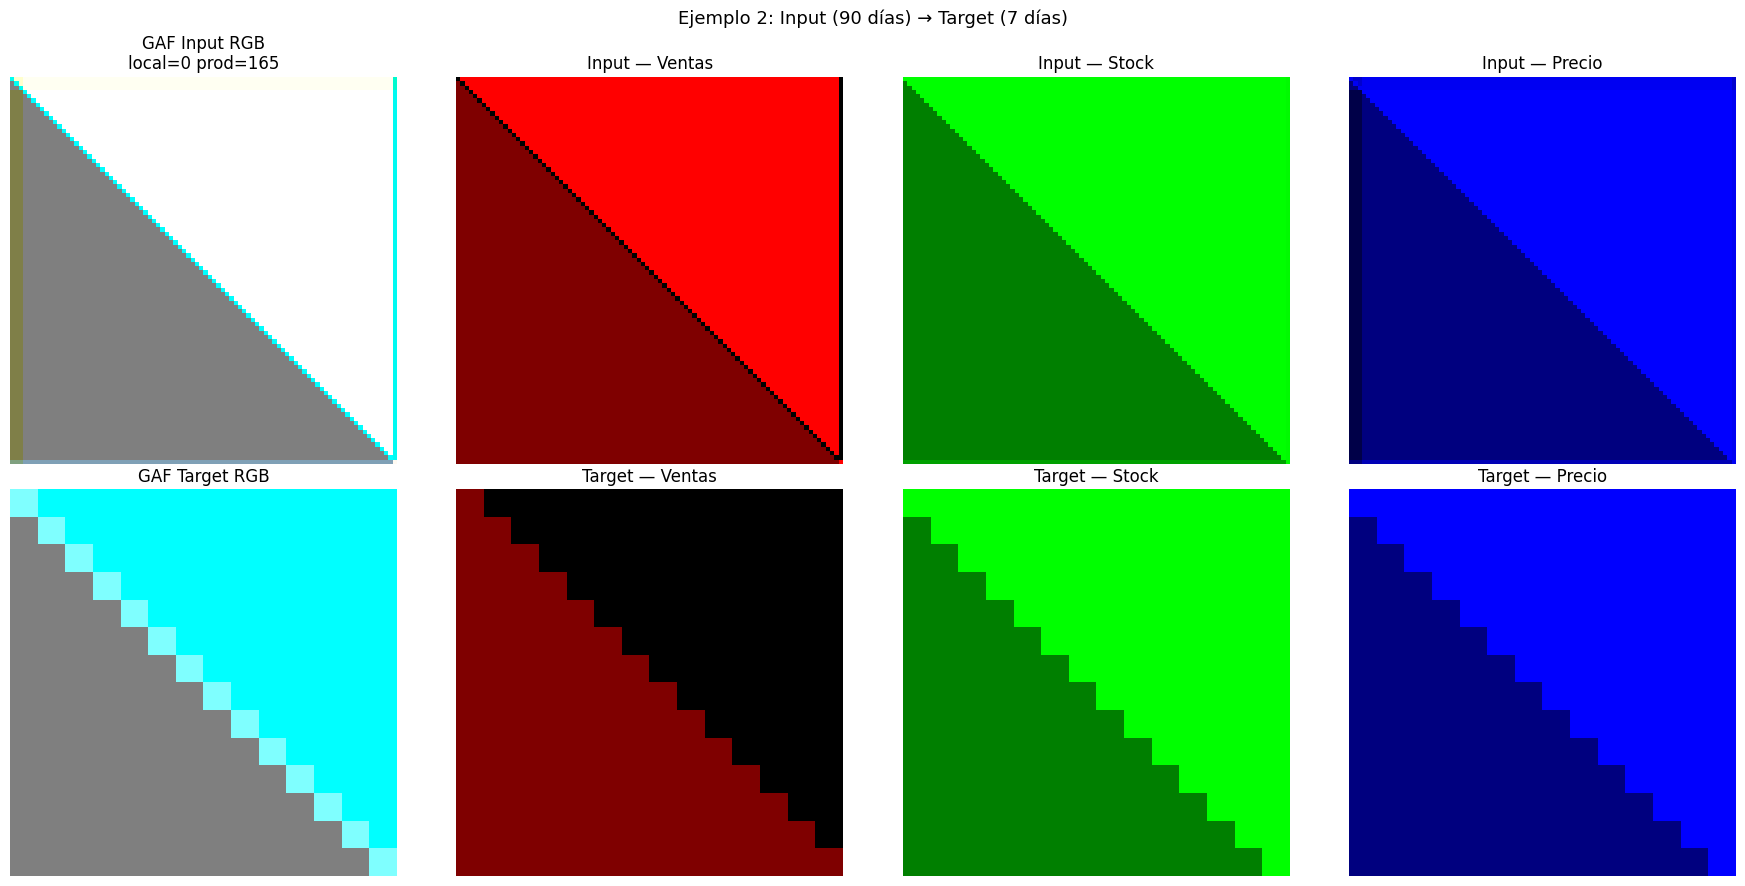

Guardado: /app/outputs/visualizations/fase3_ejemplo_2.png


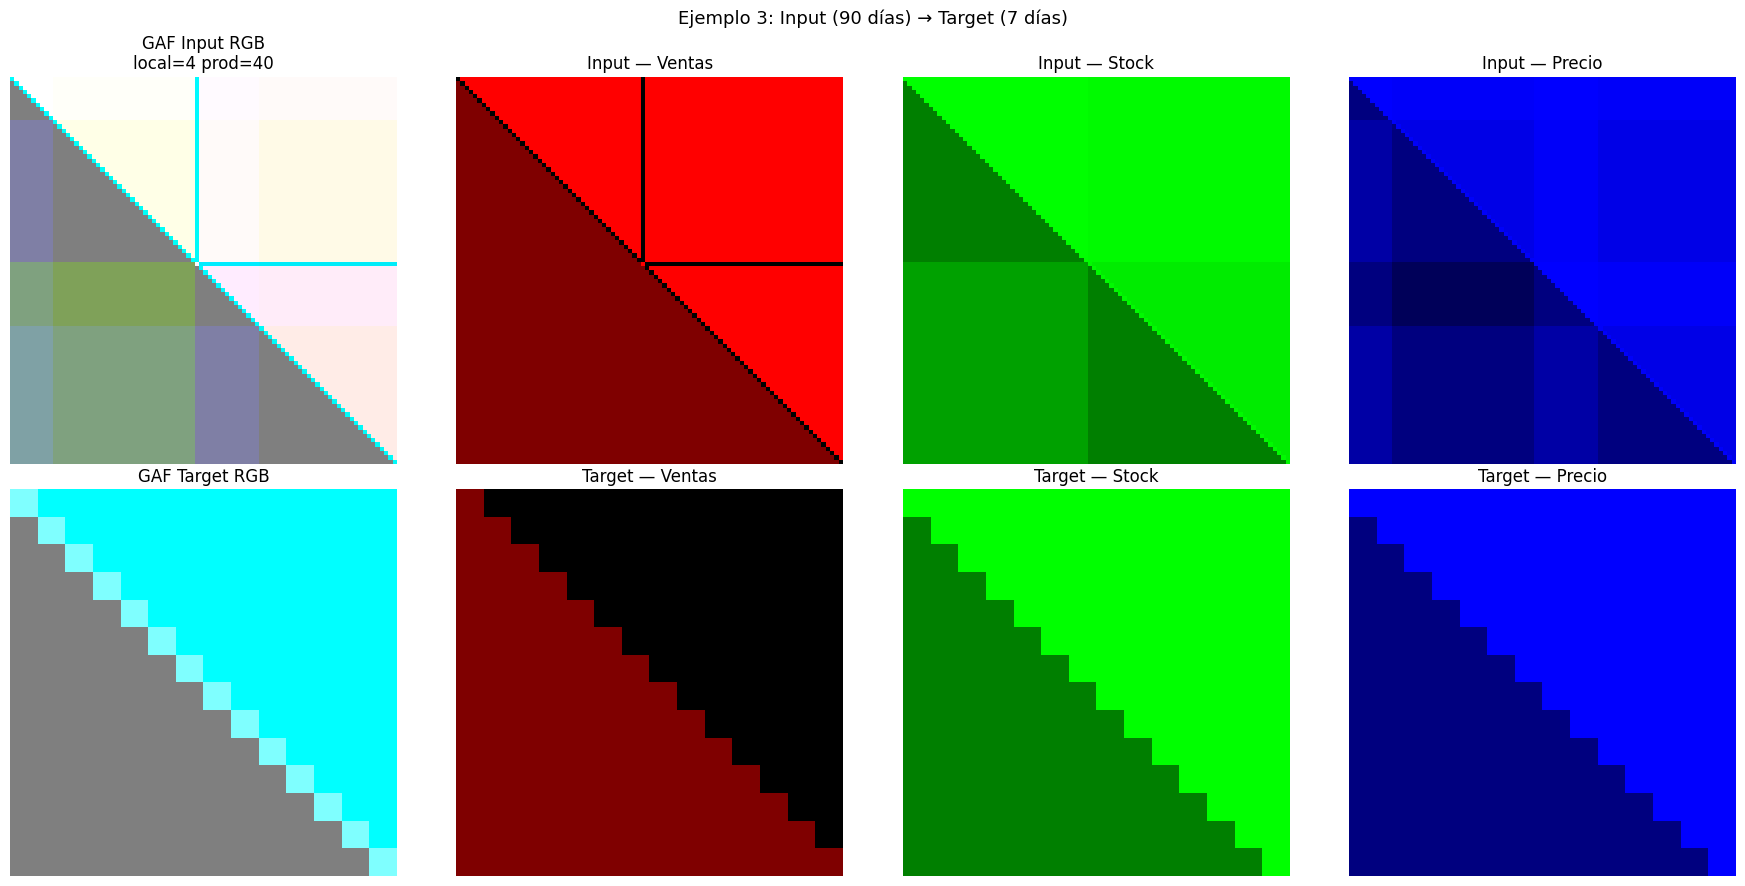

Guardado: /app/outputs/visualizations/fase3_ejemplo_3.png


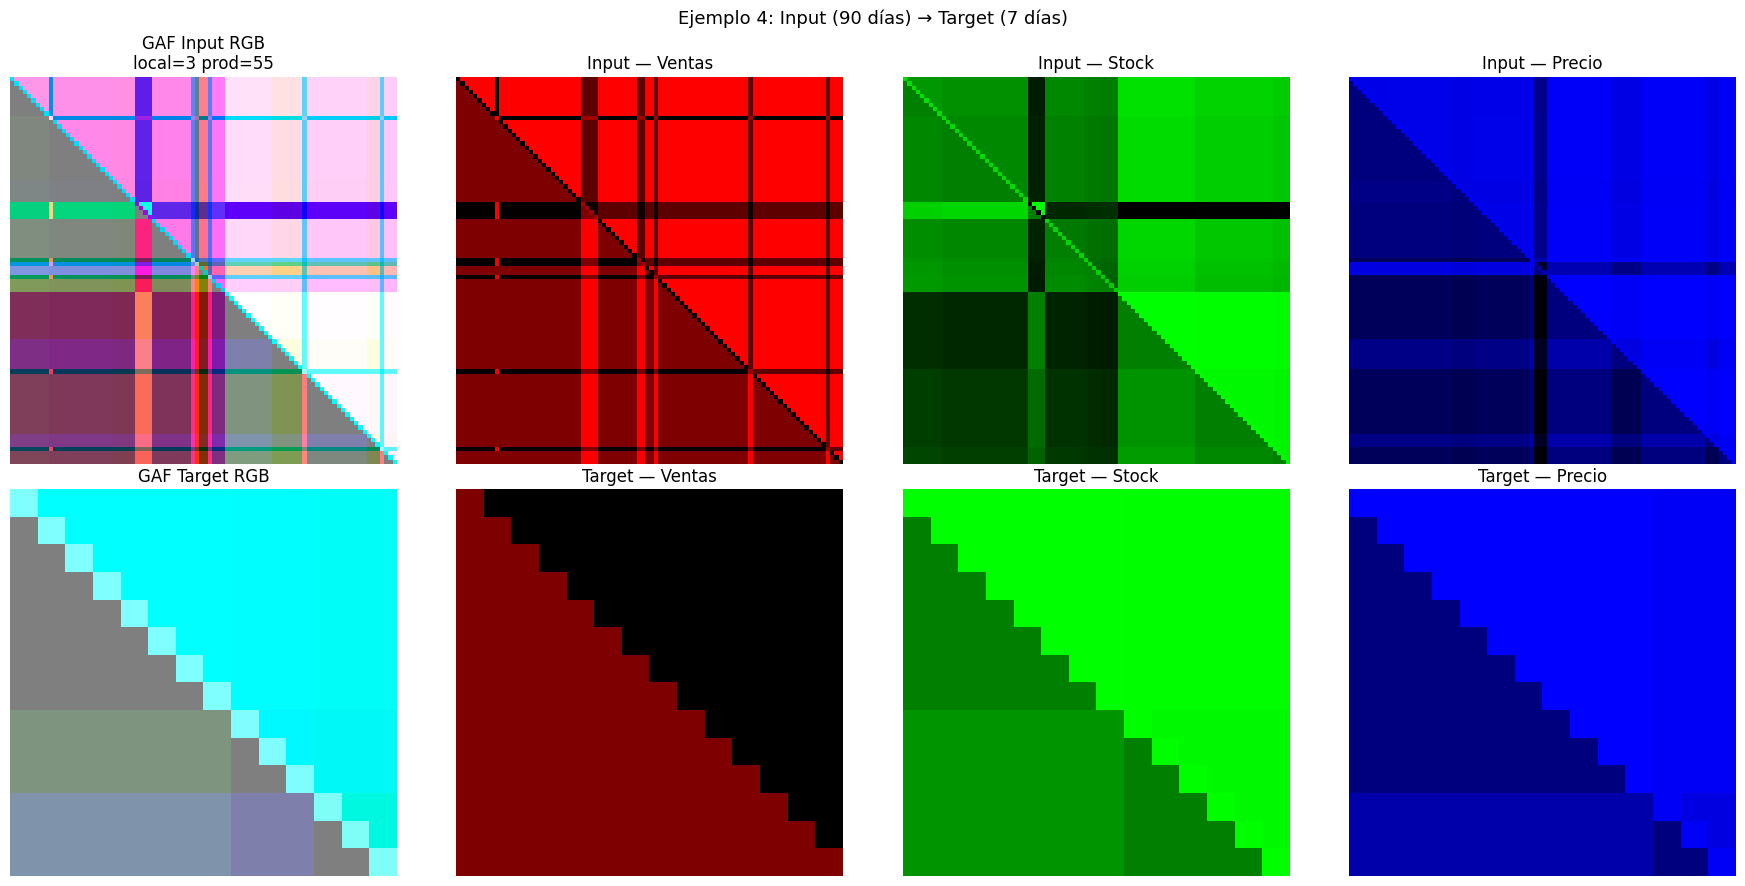

Guardado: /app/outputs/visualizations/fase3_ejemplo_4.png


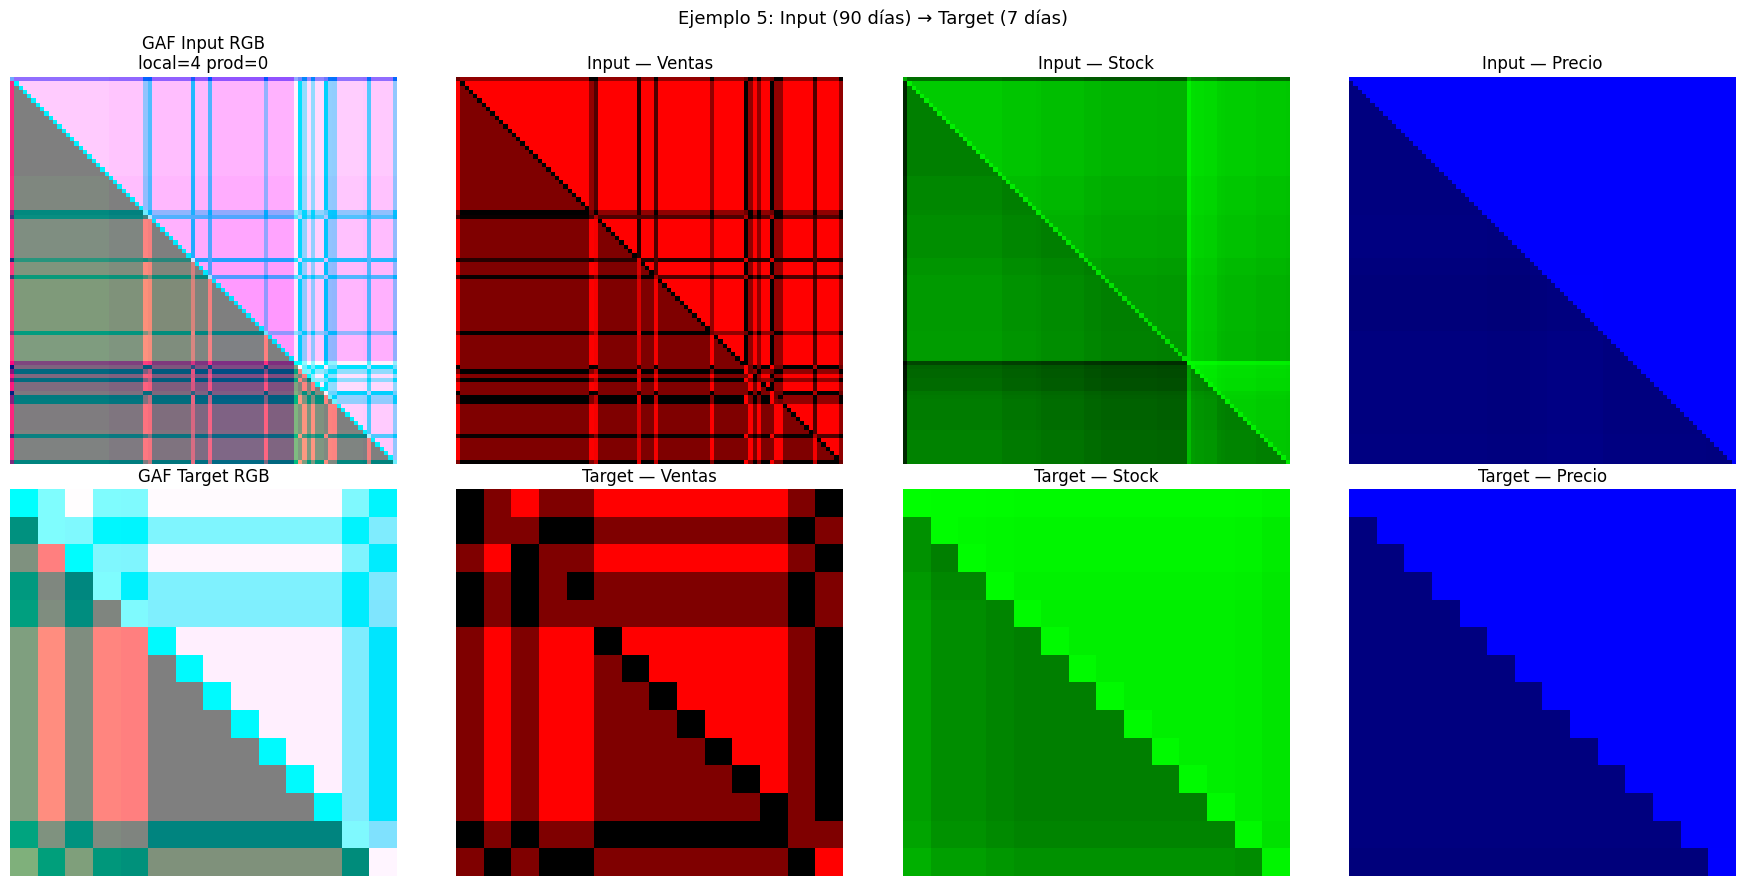

Guardado: /app/outputs/visualizations/fase3_ejemplo_5.png


In [7]:
n_ejemplos = 5
batch_iter = iter(ds_train)
inputs_batch, gaf_tgt_batch = next(batch_iter)

gaf_in_batch  = inputs_batch['gaf_input'].numpy()    # (batch, 90, 90, 3)
loc_batch     = inputs_batch['local_idx'].numpy()    # (batch,)
prod_batch    = inputs_batch['producto_idx'].numpy() # (batch,)

for idx in range(n_ejemplos):
    img_input  = gaf_in_batch[idx]           # (90, 90, 3)
    img_target = gaf_tgt_batch.numpy()[idx]  # (7, 7, 3)
    local_id   = loc_batch[idx]
    prod_id    = prod_batch[idx]

    fig, axes = plt.subplots(2, 4, figsize=(18, 9))

    axes[0,0].imshow((img_input + 1) / 2)
    axes[0,0].set_title(f'GAF Input RGB\nlocal={local_id} prod={prod_id}')
    axes[0,0].axis('off')

    for i, name in enumerate(['Ventas','Stock','Precio']):
        axes[0, i+1].imshow(gaf_canal_aislado((img_input + 1) / 2, i))
        axes[0, i+1].set_title(f'Input — {name}')
        axes[0, i+1].axis('off')

    axes[1,0].imshow((img_target + 1) / 2)
    axes[1,0].set_title('GAF Target RGB')
    axes[1,0].axis('off')

    for i, name in enumerate(['Ventas','Stock','Precio']):
        axes[1, i+1].imshow(gaf_canal_aislado((img_target + 1) / 2, i))
        axes[1, i+1].set_title(f'Target — {name}')
        axes[1, i+1].axis('off')

    plt.suptitle(f'Ejemplo {idx+1}: Input (90 días) → Target (7 días)', fontsize=13)
    plt.tight_layout()
    path = f'/app/outputs/visualizations/fase3_ejemplo_{idx+1}.png'
    plt.savefig(path, dpi=100)
    plt.show()
    print(f'Guardado: {path}')


## 5. Conteo de ejemplos por split

In [8]:
def count_samples(ds):
    return sum(inputs['gaf_input'].shape[0] for inputs, _ in ds)

n_train = count_samples(ds_train)
n_val   = count_samples(ds_val)
n_test  = count_samples(ds_test)

print('=== CONTEO DE EJEMPLOS (50 combinaciones) ===')
print(f'Train: {n_train:,}')
print(f'Val:   {n_val:,}')
print(f'Test:  {n_test:,}')
print(f'Total: {n_train + n_val + n_test:,}')


=== CONTEO DE EJEMPLOS (50 combinaciones) ===
Train: 297
Val:   2,005
Test:  136
Total: 2,438


## 6. Resumen final

In [9]:
from config import FORECAST_HORIZON

for inputs, gaf_tgt in ds_train.take(1):
    gaf_in = inputs['gaf_input']
    loc    = inputs['local_idx']
    prod   = inputs['producto_idx']

    shape_ok = (
        gaf_in.shape[1:] == (90, 90, 3) and
        gaf_tgt.shape[1:] == (FORECAST_HORIZON, FORECAST_HORIZON, 3) and
        loc.shape[0] == prod.shape[0]
    )
    rango_ok = (
        gaf_in.numpy().min() >= -1.01 and
        gaf_in.numpy().max() <= 1.01
    )
    print('=== RESUMEN FASE 3 ===')
    print(f'Shape gaf_input:                  {gaf_in.shape[1:]}')
    print(f'Shape gaf_target:                 {gaf_tgt.shape[1:]}')
    print(f'Shape input correcto (90,90,3):   {"✅" if shape_ok else "⚠️"}')
    print(f'Rango valores [-1,1]:             {"✅" if rango_ok else "⚠️"}')
    print(f'GPU detectada:                    {"✅" if tf.config.list_physical_devices("GPU") else "⚠️"}')
    print(f'Ejemplos train:                   {n_train:,}')
    print(f'Ejemplos val:                     {n_val:,}')
    print(f'Ejemplos test:                    {n_test:,}')


=== RESUMEN FASE 3 ===
Shape gaf_input:                  (90, 90, 3)
Shape gaf_target:                 (14, 14, 3)
Shape input correcto (90,90,3):   ✅
Rango valores [-1,1]:             ✅
GPU detectada:                    ✅
Ejemplos train:                   297
Ejemplos val:                     2,005
Ejemplos test:                    136


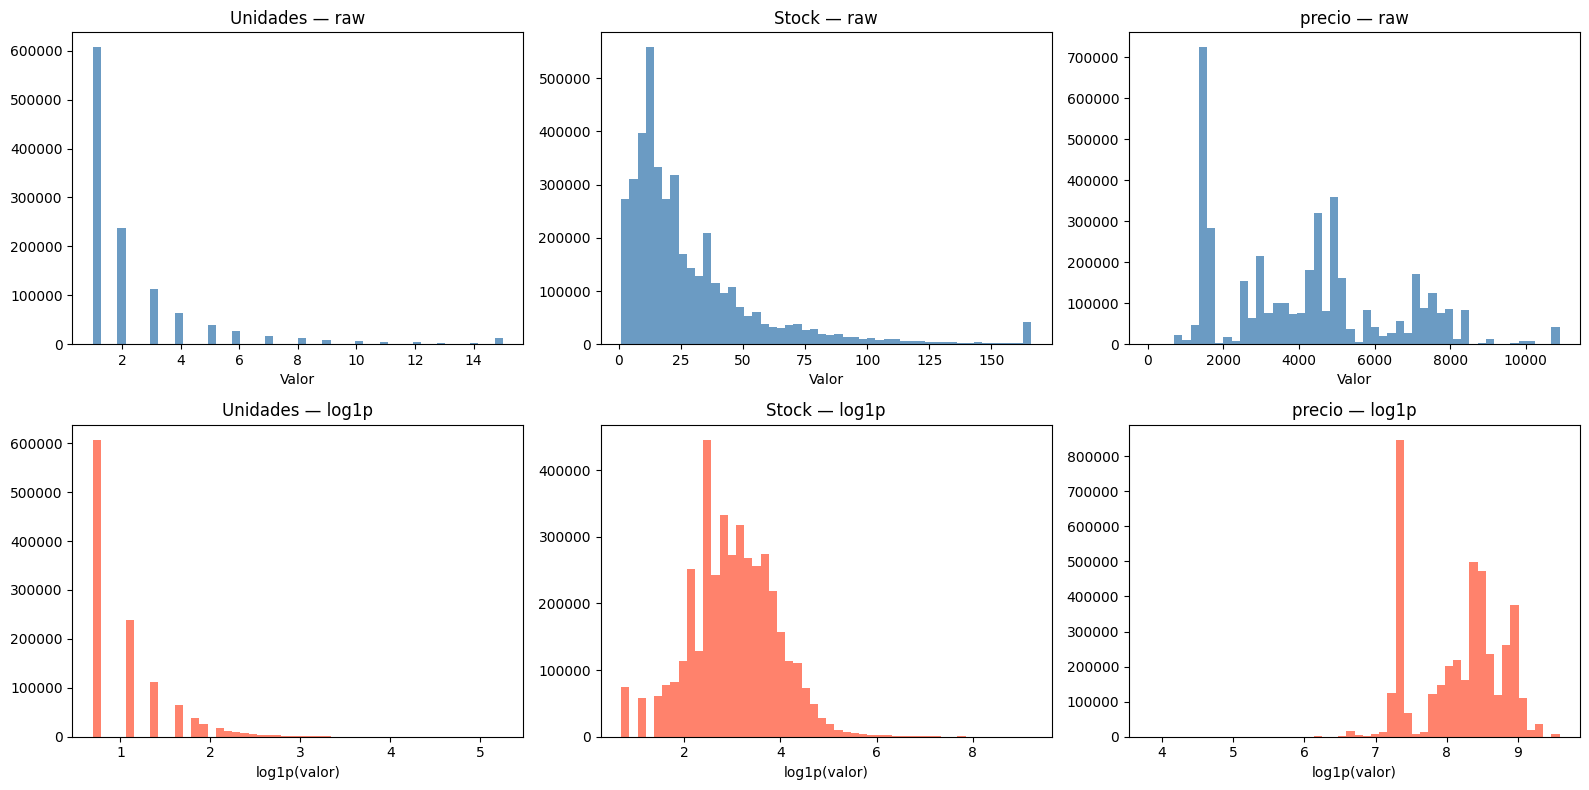

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for col, ax_raw, ax_log in zip([COL_UNIDADES, COL_STOCK, 'precio'], 
                                axes[0], axes[1]):
    data = train[col].dropna()
    data = data[data > 0]
    
    ax_raw.hist(data.clip(upper=data.quantile(0.99)), bins=50, color='steelblue', alpha=0.8)
    ax_raw.set_title(f'{col} — raw')
    ax_raw.set_xlabel('Valor')
    
    ax_log.hist(np.log1p(data), bins=50, color='tomato', alpha=0.8)
    ax_log.set_title(f'{col} — log1p')
    ax_log.set_xlabel('log1p(valor)')

plt.tight_layout()
plt.savefig('/app/outputs/visualizations/fase3_log1p_check.png', dpi=100)
plt.show()

In [ ]:
# Tomar una ventana directamente y comparar con/sin log1p
import numpy as np
from data.loader import COL_LOCAL, COL_PRODUCTO, COL_FECHA

# Tomar una combinación con ventas reales
grupo = train.groupby([COL_LOCAL, COL_PRODUCTO])
ejemplo = None
for (local, prod), g in grupo:
    if (g[COL_UNIDADES] > 0).sum() > 50:
        ejemplo = g.sort_values(COL_FECHA).head(90)
        break

ventas_raw  = ejemplo[COL_UNIDADES].values.astype(np.float32)
ventas_log  = np.log1p(ventas_raw)

print(f'Raw  — min: {ventas_raw.min():.2f}  max: {ventas_raw.max():.2f}  std: {ventas_raw.std():.2f}')
print(f'Log1p — min: {ventas_log.min():.2f}  max: {ventas_log.max():.2f}  std: {ventas_log.std():.2f}')


Raw  — min: 0.00  max: 7.00  std: 1.26
Log1p — min: 0.00  max: 2.08  std: 0.55
